In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the dataset
df = pd.read_csv('/workspaces/youth-skills-data-insights/data/participants.csv')
# 1. Number of rows and columns
print("Dataset Shape:")
print(df.shape)

# 2. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Data types and Non null values 
print("\nDataset information:")
df.info()

# 4. Missing values 
print("\nMissing values:")
print(df.isnull().sum())

# 5. Duplicate rows
print("\nDuplicate rows")
print(df.duplicated().sum())

Dataset Shape:
(15, 12)

Column names:
['participant_id', 'name', 'age', 'gender', 'region', 'education', 'program', 'attendance_pct', 'pre_score', 'post_score', 'employment_status', 'satisfaction']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   participant_id     15 non-null     str  
 1   name               15 non-null     str  
 2   age                15 non-null     int64
 3   gender             15 non-null     str  
 4   region             15 non-null     str  
 5   education          15 non-null     str  
 6   program            15 non-null     str  
 7   attendance_pct     15 non-null     int64
 8   pre_score          15 non-null     int64
 9   post_score         15 non-null     int64
 10  employment_status  15 non-null     str  
 11  satisfaction       15 non-null     int64
dtypes: int64(5), str(7)
memory usage: 1.5 

In [4]:
# Check numerical ranges

print("\nAge range:")
print(df["age"].min(), "to", df["age"].max())

print("\nAttendance range:")
print(df["attendance_pct"].min(), "to", df["attendance_pct"].max())

print("\nPre-training score range:")
print(df["pre_score"].min(), "to", df["pre_score"].max())

print("\nPost-training score range:")
print(df["post_score"].min(), "to", df["post_score"].max())

print("\nSatisfaction range:")
print(df["satisfaction"].min(), "to", df["satisfaction"].max())

print("\nGender categories:")
print(df["gender"].unique())

print("\nRegion categories:")
print(df["region"].unique())

print("\nEducation categories:")
print(df["education"].unique())

print("\nProgram categories:")
print(df["program"].unique())

print("\nEmployment status categories:")
print(df["employment_status"].unique())


Age range:
21 to 31

Attendance range:
58 to 96

Pre-training score range:
39 to 63

Post-training score range:
51 to 88

Satisfaction range:
2 to 5

Gender categories:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Region categories:
<StringArray>
['Greater Accra', 'Ashanti', 'Central', 'Eastern', 'Western']
Length: 5, dtype: str

Education categories:
<StringArray>
['Tertiary', 'SHS']
Length: 2, dtype: str

Program categories:
<StringArray>
['Data Analytics', 'Web Development', 'Cybersecurity']
Length: 3, dtype: str

Employment status categories:
<StringArray>
['Employed', 'Unemployed']
Length: 2, dtype: str


In [5]:
# Calculate score improvement
df["score_improvement"] = df["post_score"]- df["pre_score"]

print("\n Score improvement:")
print(df[["participant_id", "pre_score", "post_score", "score_improvement"]])

# Calculate average improvement
average_improvement = df["score_improvement"].mean()

print("\nAverage score improvement:")
print(average_improvement)

# Calculate employment rate
employment_rate = ((df["employment_status"]=="Employed").mean() * 100)
print("\nEmployment rate:")
print(employment_rate)

# Calculate average attendance
average_attendance = df["attendance_pct"].mean()
print("\nAverage attendance:")
print(average_attendance)

# Calculate average satisfaction
average_satisfaction = df["satisfaction"].mean()
print("\nAverage satisfaction:")
print(average_satisfaction)


 Score improvement:
   participant_id  pre_score  post_score  score_improvement
0            P001         48          78                 30
1            P002         52          74                 22
2            P003         41          65                 24
3            P004         61          88                 27
4            P005         55          81                 26
5            P006         45          57                 12
6            P007         50          82                 32
7            P008         58          69                 11
8            P009         39          76                 37
9            P010         63          85                 22
10           P011         47          72                 25
11           P012         42          51                  9
12           P013         56          86                 30
13           P014         54          79                 25
14           P015         44          68                 24

Average score impr

In [6]:
# Compare programs
program_performance = df.groupby("program").agg(
    participants=("participant_id","count"),
    average_attendance=("attendance_pct","mean"),
    average_pre_score =("pre_score", "mean"),
    average_postscore=("post_score","mean"),
    average_improvement=("score_improvement","mean"),
    average_satisfaction=("satisfaction","mean")
)

print("\nProgram Performance:")
print(program_performance)


Program Performance:
                 participants  average_attendance  average_pre_score  \
program                                                                
Cybersecurity               4           84.750000               55.0   
Data Analytics              6           84.333333               50.5   
Web Development             5           80.600000               46.4   

                 average_postscore  average_improvement  average_satisfaction  
program                                                                        
Cybersecurity                 77.0                 22.0              4.000000  
Data Analytics                75.5                 25.0              4.333333  
Web Development               70.0                 23.6              4.000000  


In [7]:
#employment rate by program
employment_by_program = df.groupby("program")["employment_status"].apply(
    lambda x: (x == "Employed").mean()*100
)
print("\nEmployment rate by program:")
print(employment_by_program)

# Correlation between attendance and score improvement
attendance_improvement_corr = df["attendance_pct"].corr(df["score_improvement"])

print("\nAttendance vs score improvement correlation:")
print(attendance_improvement_corr)



Employment rate by program:
program
Cybersecurity      75.000000
Data Analytics     66.666667
Web Development    60.000000
Name: employment_status, dtype: float64

Attendance vs score improvement correlation:
0.8937066505625479


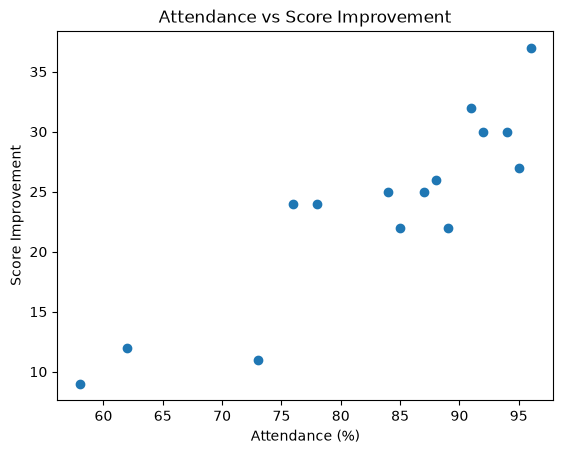

In [8]:
# Scatter plot: attendance vs score improvement
plt.scatter(df["attendance_pct"], df["score_improvement"])

plt.xlabel("Attendance (%)")
plt.ylabel("Score Improvement")
plt.title("Attendance vs Score Improvement")

plt.show()

In [9]:
employment_attendance = df.groupby("employment_status").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    average_satisfaction=("satisfaction", "mean")
)

employment_attendance

,participants,average_attendance,average_improvement,average_satisfaction
employment_status,,,,
Employed,10,90.1,27.6,4.6
Unemployed,5,69.4,16.0,3.2
